# Clase 1 – Análisis Exploratorio de Datos (EDA)
## Dataset: Vuelos en Latinoamérica

**Objetivo:** Aprender los comandos fundamentales de pandas para explorar un dataset  
**Dataset:** `vuelos_latam.csv` — 3 025 registros, 20 columnas  

| Columna | Descripción |
|---|---|
| `vuelo_id` | Identificador único del vuelo |
| `aerolinea` | Nombre de la aerolínea |
| `ciudad_origen / destino` | Ciudades de salida y llegada |
| `pais_origen` | País de salida |
| `tipo_ruta` | Doméstica o Internacional |
| `clase_servicio` | Económica, Ejecutiva, Primera |
| `mes / dia_semana` | Momento del vuelo |
| `duracion_vuelo_min` | Duración en minutos |
| `distancia_km` | Distancia del trayecto |
| `retraso_salida_min` | Minutos de retraso en salida |
| `retraso_llegada_min` | Minutos de retraso en llegada |
| `cancelado` | Si el vuelo fue cancelado |
| `causa_retraso` | Motivo del retraso (nulo si no hubo) |
| `precio_boleto_usd` | Precio del tiquete |
| `ocupacion_pct` | % de asientos ocupados |
| `num_pasajeros` | Número de pasajeros |
| `satisfaccion_cliente` | Calificación del pasajero (1-5) |
| `puntualidad_historica_pct` | % histórico de puntualidad de la aerolínea |

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

# Mostrar todas las columnas en pantalla
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Carga del dataset

In [2]:
# Cargar el CSV
df = pd.read_csv('vuelos_latam.csv')

print('Dataset cargado exitosamente')

Dataset cargado exitosamente


## 3. Exploración inicial
El primer paso siempre es *mirar* el dataset: cuántas filas, columnas y qué aspecto tienen los datos.

### 3.1 Primeras y últimas filas

In [3]:
# Ver las primeras 5 filas
df.head()

,vuelo_id,aerolinea,ciudad_origen,ciudad_destino,pais_origen,tipo_ruta,clase_servicio,mes,dia_semana,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,cancelado,causa_retraso,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
0,VL11178,Avianca,Ciudad Mx,Miami,México,Internacional,Económica,7,Viernes,186,2100,4,5,False,NaN,211.71,77.70,140,2.50,73.20
1,VL12119,Avianca,Lima,Santiago,Perú,Internacional,Económica,1,Jueves,175,2400,0,9,False,NaN,308.53,66.50,120,NaN,71.60
2,VL12681,Aeroméxico,Bogotá,Quito,Colombia,Internacional,Ejecutiva,9,Miércoles,93,1000,29,17,False,Operacional,375.98,81.90,180,3.70,74.70
3,VL11611,LATAM,Cancún,Bogotá,México,Internacional,Económica,6,Sábado,287,3500,0,0,False,NaN,338.35,77.70,140,4.20,77.50
4,VL10264,Volaris,Lima,Santiago,Perú,Internacional,Ejecutiva,6,Sábado,200,2400,0,6,False,NaN,402.55,95.90,211,3.50,70.30


In [4]:
# Ver las últimas 5 filas
df.tail()

,vuelo_id,aerolinea,ciudad_origen,ciudad_destino,pais_origen,tipo_ruta,clase_servicio,mes,dia_semana,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,cancelado,causa_retraso,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
3020,VL11092,Aeroméxico,Santiago,São Paulo,Chile,Internacional,Económica,3,Jueves,214,2700,38,42,False,Aeropuerto,284.40,71.10,128,2.00,73.90
3021,VL11768,Copa Airlines,Ciudad Mx,Bogotá,México,Internacional,Económica,6,Viernes,241,3200,0,17,False,NaN,324.72,87.20,157,3.30,82.50
3022,VL11737,Avianca,Santiago,Lima,Chile,Internacional,Económica,6,Viernes,196,2400,73,60,True,Clima,228.74,69.00,124,4.10,73.40
3023,VL11209,LATAM,Cartagena,Bogotá,Colombia,Doméstica,Ejecutiva,11,Viernes,68,650,0,4,False,NaN,166.82,94.10,207,3.40,79.50
3024,VL10641,Sky Airline,Bogotá,Miami,Colombia,Internacional,Ejecutiva,2,Viernes,321,3800,0,8,False,NaN,674.03,86.90,191,3.70,73.50


In [5]:
# Primeras 3 y últimas 3 filas — muestra rápida del contenido
print('--- INICIO ---')
display(df.head(3))
print('--- FIN ---')
display(df.tail(3))

--- INICIO ---


,vuelo_id,aerolinea,ciudad_origen,ciudad_destino,pais_origen,tipo_ruta,clase_servicio,mes,dia_semana,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,cancelado,causa_retraso,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
0,VL11178,Avianca,Ciudad Mx,Miami,México,Internacional,Económica,7,Viernes,186,2100,4,5,False,NaN,211.71,77.70,140,2.50,73.20
1,VL12119,Avianca,Lima,Santiago,Perú,Internacional,Económica,1,Jueves,175,2400,0,9,False,NaN,308.53,66.50,120,NaN,71.60
2,VL12681,Aeroméxico,Bogotá,Quito,Colombia,Internacional,Ejecutiva,9,Miércoles,93,1000,29,17,False,Operacional,375.98,81.90,180,3.70,74.70


--- FIN ---


,vuelo_id,aerolinea,ciudad_origen,ciudad_destino,pais_origen,tipo_ruta,clase_servicio,mes,dia_semana,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,cancelado,causa_retraso,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
3022,VL11737,Avianca,Santiago,Lima,Chile,Internacional,Económica,6,Viernes,196,2400,73,60,True,Clima,228.74,69.00,124,4.10,73.40
3023,VL11209,LATAM,Cartagena,Bogotá,Colombia,Doméstica,Ejecutiva,11,Viernes,68,650,0,4,False,NaN,166.82,94.10,207,3.40,79.50
3024,VL10641,Sky Airline,Bogotá,Miami,Colombia,Internacional,Ejecutiva,2,Viernes,321,3800,0,8,False,NaN,674.03,86.90,191,3.70,73.50


### 3.2 Dimensiones del dataset

In [6]:
# shape devuelve una tupla (filas, columnas)
print(f'Filas:    {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'Total de celdas: {df.shape[0] * df.shape[1]:,}')

Filas:    3025
Columnas: 20
Total de celdas: 60,500


### 3.3 Nombres de columnas

In [7]:
# Lista de nombres de columnas
print(df.columns.tolist())

['vuelo_id', 'aerolinea', 'ciudad_origen', 'ciudad_destino', 'pais_origen', 'tipo_ruta', 'clase_servicio', 'mes', 'dia_semana', 'duracion_vuelo_min', 'distancia_km', 'retraso_salida_min', 'retraso_llegada_min', 'cancelado', 'causa_retraso', 'precio_boleto_usd', 'ocupacion_pct', 'num_pasajeros', 'satisfaccion_cliente', 'puntualidad_historica_pct']


### 3.4 Tipos de datos (`dtypes`)

In [8]:
# Tipo de dato de cada columna
df.dtypes

vuelo_id                         str
aerolinea                        str
ciudad_origen                    str
ciudad_destino                   str
pais_origen                      str
tipo_ruta                        str
clase_servicio                   str
mes                            int64
dia_semana                       str
duracion_vuelo_min             int64
distancia_km                   int64
retraso_salida_min             int64
retraso_llegada_min            int64
cancelado                       bool
causa_retraso                    str
precio_boleto_usd            float64
ocupacion_pct                float64
num_pasajeros                  int64
satisfaccion_cliente         float64
puntualidad_historica_pct    float64
dtype: object

### 3.5 Resumen general (`info`)
`info()` combina tipos de datos, conteo de valores no-nulos y uso de memoria — ideal para ver de un vistazo dónde hay datos faltantes.

In [9]:
# Resumen general: tipos, conteos y memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   vuelo_id                   3025 non-null   str    
 1   aerolinea                  3025 non-null   str    
 2   ciudad_origen              3025 non-null   str    
 3   ciudad_destino             3025 non-null   str    
 4   pais_origen                2964 non-null   str    
 5   tipo_ruta                  3025 non-null   str    
 6   clase_servicio             3025 non-null   str    
 7   mes                        3025 non-null   int64  
 8   dia_semana                 3025 non-null   str    
 9   duracion_vuelo_min         3025 non-null   int64  
 10  distancia_km               3025 non-null   int64  
 11  retraso_salida_min         3025 non-null   int64  
 12  retraso_llegada_min        3025 non-null   int64  
 13  cancelado                  3025 non-null   bool   
 14  cau

## 4. Estadísticas descriptivas
`describe()` calcula conteo, media, desviación estándar, mínimo, cuartiles y máximo para todas las columnas numéricas.

In [10]:
# Estadísticas para columnas numéricas
df.describe()

,mes,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
count,3025.00,3025.00,3025.00,3025.00,3025.00,2940.00,3025.00,3025.00,2830.00,3025.00
mean,6.35,186.37,2281.56,15.40,17.25,369.75,79.20,154.24,3.59,74.75
std,3.46,83.26,1099.30,54.26,52.99,479.82,11.77,32.93,0.88,5.06
min,1.00,40.00,550.00,0.00,0.00,30.00,26.50,58.00,1.00,60.90
25%,3.00,105.00,1000.00,0.00,0.00,154.41,71.20,133.00,3.00,71.50
50%,6.00,203.00,2400.00,0.00,5.00,270.16,79.40,151.00,3.60,74.70
75%,9.00,256.00,3200.00,14.00,16.00,407.48,87.70,170.00,4.20,78.50
max,12.00,339.00,3800.00,717.00,750.00,5835.61,100.00,300.00,5.00,86.40


In [11]:
# Incluir también columnas de texto y booleanas
df.describe(include='all')

,vuelo_id,aerolinea,ciudad_origen,ciudad_destino,pais_origen,tipo_ruta,clase_servicio,mes,dia_semana,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,cancelado,causa_retraso,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
count,3025,3025,3025,3025,2964,3025,3025,3025.00,3025,3025.00,3025.00,3025.00,3025.00,3025,706,2940.00,3025.00,3025.00,2830.00,3025.00
unique,3000,7,9,10,5,2,3,NaN,7,NaN,NaN,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN
top,VL11166,LATAM,Bogotá,Bogotá,Colombia,Internacional,Económica,NaN,Sábado,NaN,NaN,NaN,NaN,False,Clima,NaN,NaN,NaN,NaN,NaN
freq,2,672,705,590,1045,2164,2238,NaN,571,NaN,NaN,NaN,NaN,2931,190,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.35,NaN,186.37,2281.56,15.40,17.25,NaN,NaN,369.75,79.20,154.24,3.59,74.75
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.46,NaN,83.26,1099.30,54.26,52.99,NaN,NaN,479.82,11.77,32.93,0.88,5.06
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,40.00,550.00,0.00,0.00,NaN,NaN,30.00,26.50,58.00,1.00,60.90
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,NaN,105.00,1000.00,0.00,0.00,NaN,NaN,154.41,71.20,133.00,3.00,71.50
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.00,NaN,203.00,2400.00,0.00,5.00,NaN,NaN,270.16,79.40,151.00,3.60,74.70
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.00,NaN,256.00,3200.00,14.00,16.00,NaN,NaN,407.48,87.70,170.00,4.20,78.50


In [12]:
# Estadísticas individuales para retraso_salida_min
col = 'retraso_salida_min'
print(f'Media:    {df[col].mean():.1f} min')
print(f'Mediana:  {df[col].median():.1f} min')
print(f'Máximo:   {df[col].max():.1f} min')
print(f'Mínimo:   {df[col].min():.1f} min')
print(f'Std Dev:  {df[col].std():.1f} min')
print(f'Q1 (25%): {df[col].quantile(0.25):.1f} min')
print(f'Q3 (75%): {df[col].quantile(0.75):.1f} min')

Media:    15.4 min
Mediana:  0.0 min
Máximo:   717.0 min
Mínimo:   0.0 min
Std Dev:  54.3 min
Q1 (25%): 0.0 min
Q3 (75%): 14.0 min


## 5. Valores nulos (missing values)
Los valores nulos pueden afectar gravemente el análisis si no se detectan a tiempo.  
En este dataset `causa_retraso` es **nulo por diseño** cuando el vuelo llegó puntual.

In [13]:
# Contar nulos por columna
nulos = df.isnull().sum()
nulos[nulos > 0]

pais_origen               61
causa_retraso           2319
precio_boleto_usd         85
satisfaccion_cliente     195
dtype: int64

In [14]:
# Porcentaje de nulos por columna
pct_nulos = (df.isnull().sum() / len(df) * 100).round(2)
pct_nulos[pct_nulos > 0].sort_values(ascending=False)

causa_retraso          76.66
satisfaccion_cliente    6.45
precio_boleto_usd       2.81
pais_origen             2.02
dtype: float64

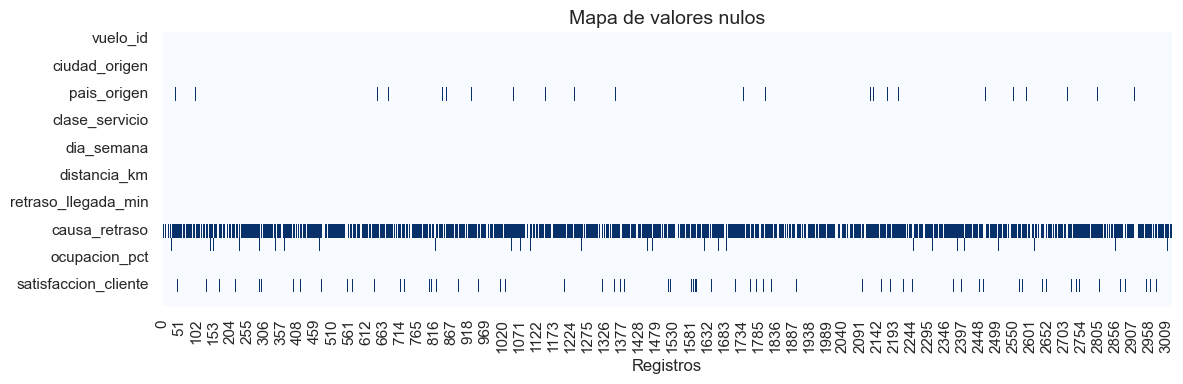

In [15]:
# Mapa de calor de valores nulos — cada celda azul = dato faltante
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='Blues', ax=ax)
ax.set_title('Mapa de valores nulos', fontsize=14)
ax.set_xlabel('Registros')
plt.tight_layout()
plt.show()

In [16]:
# ¿Cuántas filas tienen AL MENOS un valor nulo?
filas_con_nulo = df.isnull().any(axis=1).sum()
print(f'{filas_con_nulo} filas ({filas_con_nulo/len(df)*100:.1f}%) tienen al menos un nulo')

2395 filas (79.2%) tienen al menos un nulo


## 6. Detección de duplicados
Los registros duplicados inflan conteos y distorsionan promedios.

In [17]:
# Contar filas completamente duplicadas
n_dup = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_dup}')

# Ver los duplicados
df[df.duplicated(keep=False)].sort_values('vuelo_id').head(10)

Filas duplicadas encontradas: 25


,vuelo_id,aerolinea,ciudad_origen,ciudad_destino,pais_origen,tipo_ruta,clase_servicio,mes,dia_semana,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,cancelado,causa_retraso,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
952,VL10568,Volaris,Lima,Santiago,Perú,Internacional,Económica,1,Viernes,202,2400,0,0,False,NaN,271.83,74.20,134,4.20,67.60
1573,VL10568,Volaris,Lima,Santiago,Perú,Internacional,Económica,1,Viernes,202,2400,0,0,False,NaN,271.83,74.20,134,4.20,67.60
107,VL10584,Aeroméxico,Cancún,Bogotá,México,Internacional,Económica,1,Domingo,302,3500,9,3,False,NaN,363.35,68.20,123,4.30,76.30
439,VL10584,Aeroméxico,Cancún,Bogotá,México,Internacional,Económica,1,Domingo,302,3500,9,3,False,NaN,363.35,68.20,123,4.30,76.30
1500,VL10718,Aeroméxico,Ciudad Mx,Cancún,México,Doméstica,Económica,1,Martes,132,1600,0,3,False,NaN,200.62,77.90,140,2.70,75.20
2273,VL10718,Aeroméxico,Ciudad Mx,Cancún,México,Doméstica,Económica,1,Martes,132,1600,0,3,False,NaN,200.62,77.90,140,2.70,75.20
1340,VL10891,Aeroméxico,Bogotá,Quito,Colombia,Internacional,Ejecutiva,10,Lunes,73,1000,17,11,False,Operacional,190.86,65.50,144,4.40,76.10
2602,VL10891,Aeroméxico,Bogotá,Quito,Colombia,Internacional,Ejecutiva,10,Lunes,73,1000,17,11,False,Operacional,190.86,65.50,144,4.40,76.10
1498,VL11111,Aeroméxico,Santiago,Lima,Chile,Internacional,Ejecutiva,2,Lunes,189,2400,0,0,True,NaN,651.43,70.50,155,3.20,73.90
2177,VL11111,Aeroméxico,Santiago,Lima,Chile,Internacional,Ejecutiva,2,Lunes,189,2400,0,0,True,NaN,651.43,70.50,155,3.20,73.90


In [18]:
# Eliminar duplicados y verificar
df_limpio = df.drop_duplicates()
print(f'Filas antes: {len(df)}')
print(f'Filas después: {len(df_limpio)}')
print(f'Eliminadas: {len(df) - len(df_limpio)}')

# Trabajaremos con el dataset sin duplicados
df = df_limpio.reset_index(drop=True)

Filas antes: 3025
Filas después: 3000
Eliminadas: 25


## 7. Variables categóricas
`value_counts()` y `unique()` son clave para entender la distribución de las categorías.

### 7.1 Valores únicos por columna

In [19]:
# Cuántos valores únicos tiene cada columna
df.nunique().sort_values()

tipo_ruta                       2
cancelado                       2
clase_servicio                  3
pais_origen                     5
causa_retraso                   5
dia_semana                      7
aerolinea                       7
ciudad_origen                   9
ciudad_destino                 10
mes                            12
distancia_km                   14
satisfaccion_cliente           41
retraso_salida_min            139
retraso_llegada_min           145
num_pasajeros                 192
puntualidad_historica_pct     239
duracion_vuelo_min            294
ocupacion_pct                 495
precio_boleto_usd            2802
vuelo_id                     3000
dtype: int64

### 7.2 Frecuencia de valores — `value_counts()`

In [20]:
# ¿Cuántos vuelos operó cada aerolínea?
df['aerolinea'].value_counts()

aerolinea
LATAM            671
Avianca          555
Aeroméxico       532
Copa Airlines    414
Volaris          347
Sky Airline      244
Viva Air         237
Name: count, dtype: int64

In [21]:
# En porcentaje (normalize=True)
df['aerolinea'].value_counts(normalize=True).round(3) * 100

aerolinea
LATAM           22.40
Avianca         18.50
Aeroméxico      17.70
Copa Airlines   13.80
Volaris         11.60
Sky Airline      8.10
Viva Air         7.90
Name: proportion, dtype: float64

In [22]:
# Distribución de clase de servicio
df['clase_servicio'].value_counts()

clase_servicio
Económica    2225
Ejecutiva     612
Primera       163
Name: count, dtype: int64

In [23]:
# Distribución de causa de retraso (excluyendo nulos)
df['causa_retraso'].value_counts(dropna=True)

causa_retraso
Clima          190
Operacional    168
Aeropuerto     166
Tripulación    120
Mecánico        57
Name: count, dtype: int64

### 7.3 Valores únicos — `unique()`

In [24]:
# ¿Qué aerolíneas hay en el dataset?
print('Aerolíneas:', df['aerolinea'].unique())

# ¿Qué países de origen?
print('Países de origen:', df['pais_origen'].dropna().unique())

# ¿Qué días de la semana?
print('Días:', df['dia_semana'].unique())

Aerolíneas: <ArrowStringArray>
[      'Avianca',    'Aeroméxico',         'LATAM',       'Volaris',
 'Copa Airlines',   'Sky Airline',      'Viva Air']
Length: 7, dtype: str
Países de origen: <ArrowStringArray>
['México', 'Perú', 'Colombia', 'Argentina', 'Chile']
Length: 5, dtype: str
Días: <ArrowStringArray>
['Viernes', 'Jueves', 'Miércoles', 'Sábado', 'Martes', 'Lunes', 'Domingo']
Length: 7, dtype: str


### 7.4 Visualizaciones de variables categóricas

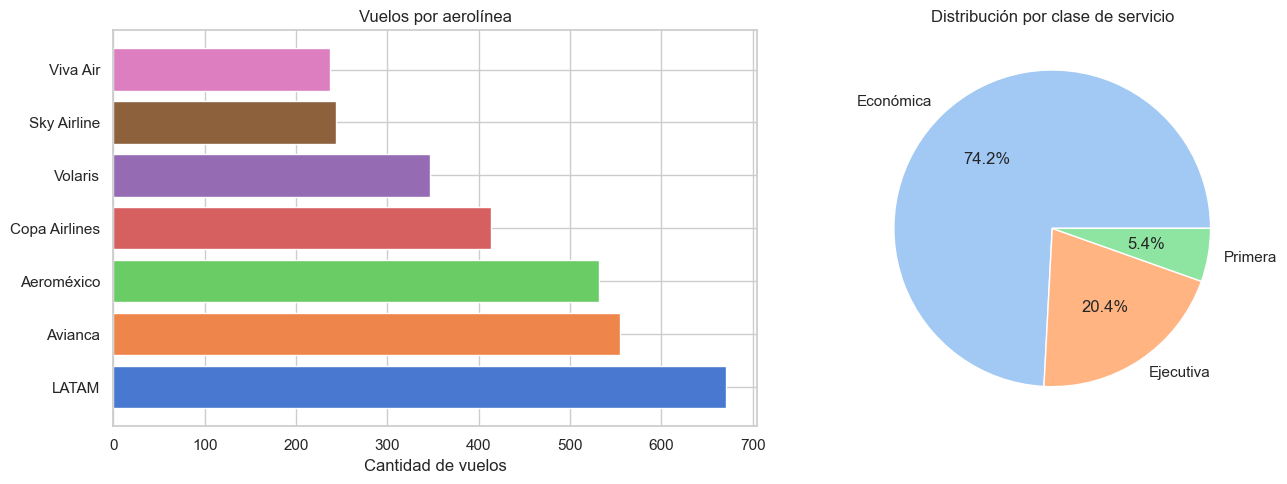

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vuelos por aerolínea
conteo_aero = df['aerolinea'].value_counts()
axes[0].barh(conteo_aero.index, conteo_aero.values, color=sns.color_palette('muted', len(conteo_aero)))
axes[0].set_title('Vuelos por aerolínea')
axes[0].set_xlabel('Cantidad de vuelos')

# Vuelos por clase de servicio
conteo_clase = df['clase_servicio'].value_counts()
axes[1].pie(conteo_clase.values, labels=conteo_clase.index,
            autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1].set_title('Distribución por clase de servicio')

plt.tight_layout()
plt.show()

C:\Users\juan.a.costa\AppData\Local\Temp\ipykernel_35068\3051269999.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_dia.index, y=conteo_dia.values, palette='Blues_d')


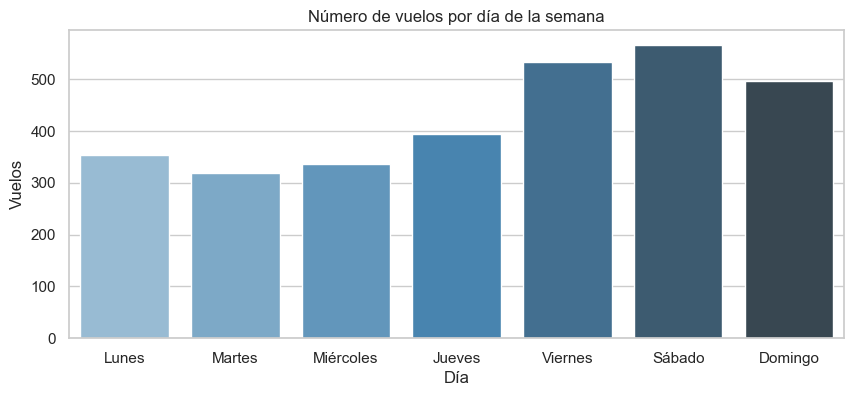

In [26]:
# Vuelos por día de la semana
orden_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
conteo_dia = df['dia_semana'].value_counts().reindex(orden_dias)

plt.figure(figsize=(10, 4))
sns.barplot(x=conteo_dia.index, y=conteo_dia.values, palette='Blues_d')
plt.title('Número de vuelos por día de la semana')
plt.xlabel('Día')
plt.ylabel('Vuelos')
plt.show()

## 8. Distribuciones y outliers
Los **histogramas** muestran la forma de la distribución; los **boxplots** revelan outliers  
(valores extremos que se alejan de la caja IQR).

### 8.1 Histogramas — distribución de variables numéricas

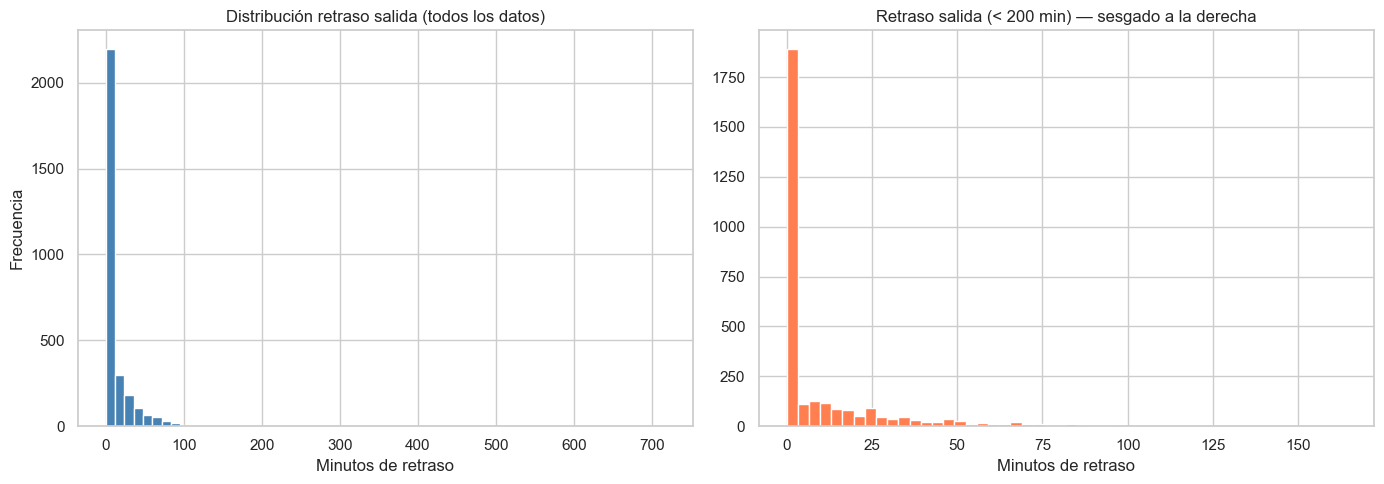

La mayoría de los vuelos tienen 0 min de retraso (distribución muy sesgada)


In [27]:
# Histograma de retraso en la salida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con todos los datos (incluye outliers extremos)
axes[0].hist(df['retraso_salida_min'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución retraso salida (todos los datos)')
axes[0].set_xlabel('Minutos de retraso')
axes[0].set_ylabel('Frecuencia')

# Sin outliers extremos (mejor visibilidad de la forma)
sin_outlier = df[df['retraso_salida_min'] < 200]['retraso_salida_min']
axes[1].hist(sin_outlier, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Retraso salida (< 200 min) — sesgado a la derecha')
axes[1].set_xlabel('Minutos de retraso')

plt.tight_layout()
plt.show()
print('La mayoría de los vuelos tienen 0 min de retraso (distribución muy sesgada)')

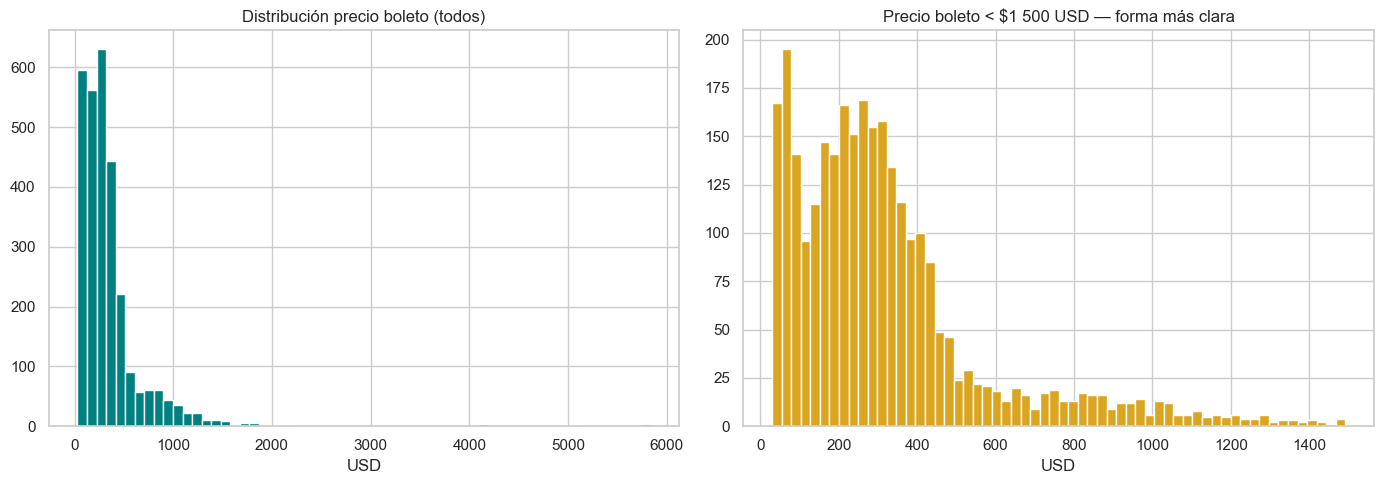

In [28]:
# Histograma de precio del boleto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['precio_boleto_usd'].dropna(), bins=60, color='teal', edgecolor='white')
axes[0].set_title('Distribución precio boleto (todos)')
axes[0].set_xlabel('USD')

# Sin outliers extremos de precio
precio_filtrado = df[df['precio_boleto_usd'] < 1500]['precio_boleto_usd']
axes[1].hist(precio_filtrado.dropna(), bins=60, color='goldenrod', edgecolor='white')
axes[1].set_title('Precio boleto < $1 500 USD — forma más clara')
axes[1].set_xlabel('USD')

plt.tight_layout()
plt.show()

### 8.2 Boxplots — detección visual de outliers
Los puntos fuera de los **bigotes** del boxplot son posibles outliers.

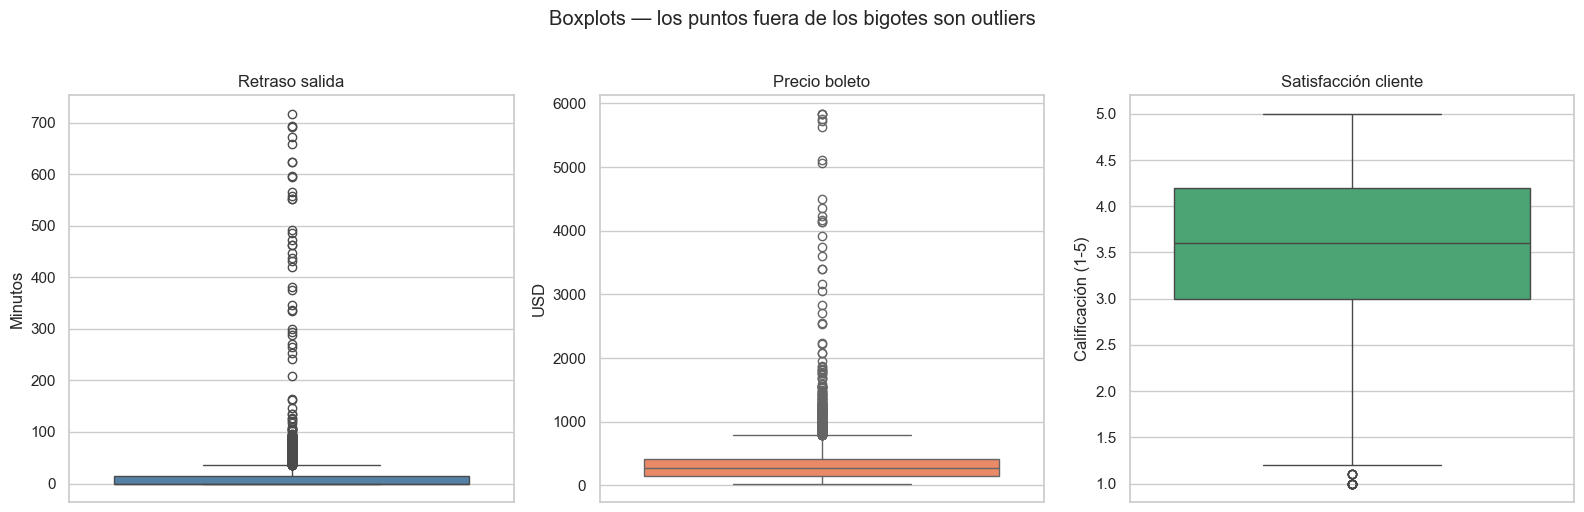

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['retraso_salida_min'], ax=axes[0], color='steelblue')
axes[0].set_title('Retraso salida')
axes[0].set_ylabel('Minutos')

sns.boxplot(y=df['precio_boleto_usd'].dropna(), ax=axes[1], color='coral')
axes[1].set_title('Precio boleto')
axes[1].set_ylabel('USD')

sns.boxplot(y=df['satisfaccion_cliente'].dropna(), ax=axes[2], color='mediumseagreen')
axes[2].set_title('Satisfacción cliente')
axes[2].set_ylabel('Calificación (1-5)')

plt.suptitle('Boxplots — los puntos fuera de los bigotes son outliers', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\juan.a.costa\AppData\Local\Temp\ipykernel_35068\1686632130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='clase_servicio', y='precio_boleto_usd',


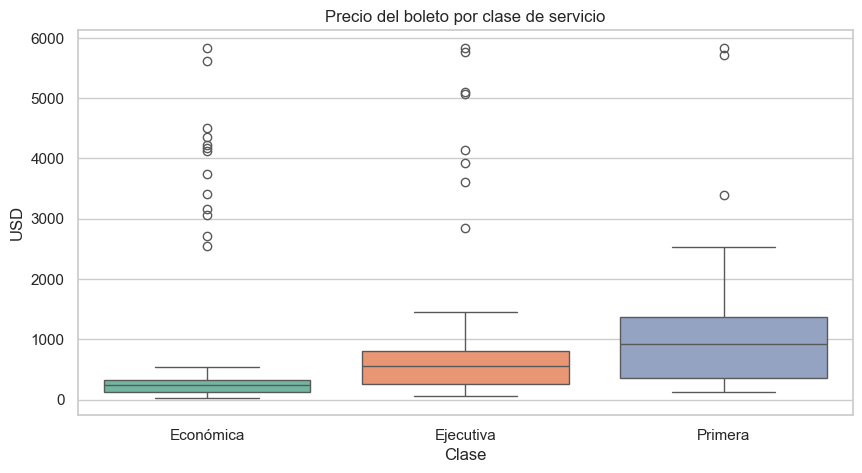

Se confirma: Primera clase tiene precios mucho más altos y mayor variabilidad


In [30]:
# Boxplot por grupo: precio según clase de servicio
plt.figure(figsize=(10, 5))
orden_clase = ['Económica', 'Ejecutiva', 'Primera']
sns.boxplot(data=df, x='clase_servicio', y='precio_boleto_usd',
            order=orden_clase, palette='Set2')
plt.title('Precio del boleto por clase de servicio')
plt.xlabel('Clase')
plt.ylabel('USD')
plt.show()
print('Se confirma: Primera clase tiene precios mucho más altos y mayor variabilidad')

## 9. Correlaciones
`corr()` mide la relación lineal entre pares de variables numéricas.  
- **+1** = correlación positiva perfecta  
- **−1** = correlación negativa perfecta  
- **0** = sin relación lineal

In [31]:
# Matriz de correlaciones
numericas = ['duracion_vuelo_min','distancia_km','retraso_salida_min',
             'retraso_llegada_min','precio_boleto_usd','ocupacion_pct',
             'num_pasajeros','satisfaccion_cliente','puntualidad_historica_pct']

corr_matrix = df[numericas].corr()
corr_matrix.round(2)

,duracion_vuelo_min,distancia_km,retraso_salida_min,retraso_llegada_min,precio_boleto_usd,ocupacion_pct,num_pasajeros,satisfaccion_cliente,puntualidad_historica_pct
duracion_vuelo_min,1.00,0.99,0.04,0.03,0.31,-0.12,-0.11,0.00,-0.01
distancia_km,0.99,1.00,0.04,0.04,0.32,-0.12,-0.12,0.01,-0.01
retraso_salida_min,0.04,0.04,1.00,0.99,-0.01,-0.01,-0.03,-0.23,0.02
retraso_llegada_min,0.03,0.04,0.99,1.00,-0.02,-0.01,-0.03,-0.25,0.02
precio_boleto_usd,0.31,0.32,-0.01,-0.02,1.00,-0.06,0.27,0.10,-0.00
ocupacion_pct,-0.12,-0.12,-0.01,-0.01,-0.06,1.00,0.69,-0.01,0.00
num_pasajeros,-0.11,-0.12,-0.03,-0.03,0.27,0.69,1.00,0.11,-0.00
satisfaccion_cliente,0.00,0.01,-0.23,-0.25,0.10,-0.01,0.11,1.00,0.01
puntualidad_historica_pct,-0.01,-0.01,0.02,0.02,-0.00,0.00,-0.00,0.01,1.00


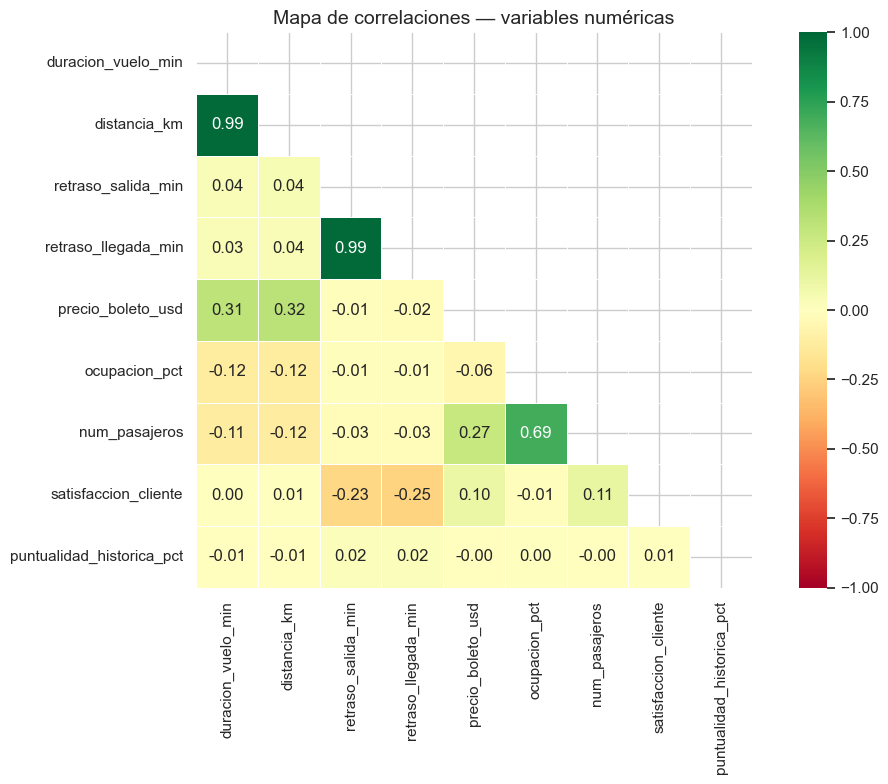

In [32]:
# Mapa de calor de correlaciones
plt.figure(figsize=(11, 8))
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, mask=mascara,
            linewidths=0.5, square=True)
plt.title('Mapa de correlaciones — variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

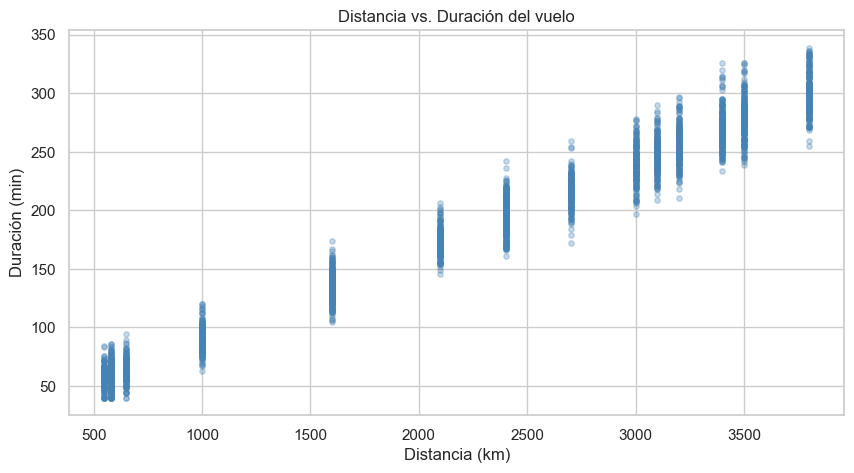

Correlación distancia-duración: 0.986


In [33]:
# Scatter plot: distancia vs. duración del vuelo
plt.figure(figsize=(10, 5))
plt.scatter(df['distancia_km'], df['duracion_vuelo_min'],
            alpha=0.3, color='steelblue', s=15)
plt.title('Distancia vs. Duración del vuelo')
plt.xlabel('Distancia (km)')
plt.ylabel('Duración (min)')
plt.show()
print(f"Correlación distancia-duración: {df['distancia_km'].corr(df['duracion_vuelo_min']):.3f}")

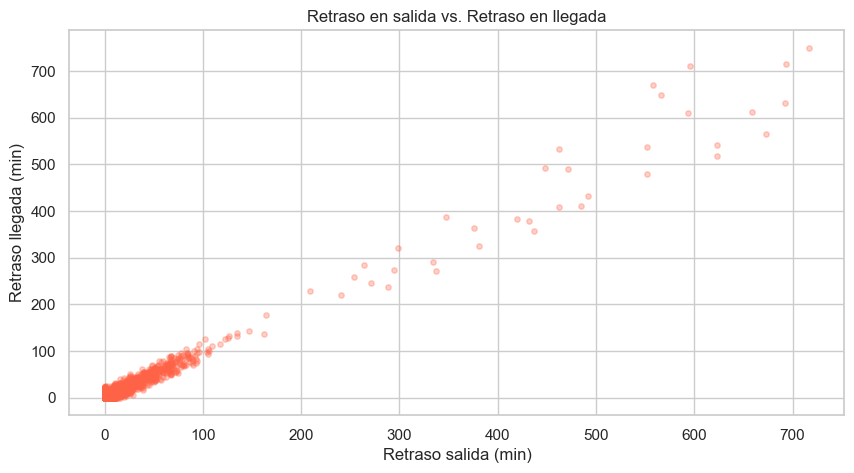

Un retraso en salida casi siempre implica un retraso en llegada


In [34]:
# Scatter plot: retraso salida vs. retraso llegada
plt.figure(figsize=(10, 5))
plt.scatter(df['retraso_salida_min'], df['retraso_llegada_min'],
            alpha=0.3, color='tomato', s=15)
plt.title('Retraso en salida vs. Retraso en llegada')
plt.xlabel('Retraso salida (min)')
plt.ylabel('Retraso llegada (min)')
plt.show()
print('Un retraso en salida casi siempre implica un retraso en llegada')

## 10. Análisis por grupos — `groupby()`
`groupby()` agrupa filas por una categoría y permite calcular estadísticas por grupo.

In [35]:
# Retraso promedio por aerolínea (ordenado de mayor a menor)
retraso_por_aero = (
    df.groupby('aerolinea')['retraso_salida_min']
    .mean()
    .round(1)
    .sort_values(ascending=False)
)
print('Retraso promedio en salida (min) por aerolínea:')
retraso_por_aero

Retraso promedio en salida (min) por aerolínea:


aerolinea
Copa Airlines   18.80
Aeroméxico      16.20
Sky Airline     16.10
Volaris         14.90
Avianca         14.70
LATAM           14.20
Viva Air        13.70
Name: retraso_salida_min, dtype: float64

In [36]:
# Satisfacción promedio por clase de servicio
sat_clase = (
    df.groupby('clase_servicio')['satisfaccion_cliente']
    .agg(['mean', 'median', 'count'])
    .round(2)
)
sat_clase.columns = ['Promedio', 'Mediana', 'Vuelos']
sat_clase

,Promedio,Mediana,Vuelos
clase_servicio,,,
Económica,3.50,3.50,2090
Ejecutiva,3.79,3.80,568
Primera,4.01,4.10,147


In [37]:
# Precio promedio por tipo de ruta y clase
precio_grupo = (
    df.groupby(['tipo_ruta', 'clase_servicio'])['precio_boleto_usd']
    .mean()
    .round(2)
    .unstack()
)
precio_grupo

clase_servicio,Económica,Ejecutiva,Primera
tipo_ruta,,,
Doméstica,114.54,299.37,607.78
Internacional,308.83,750.70,1186.83


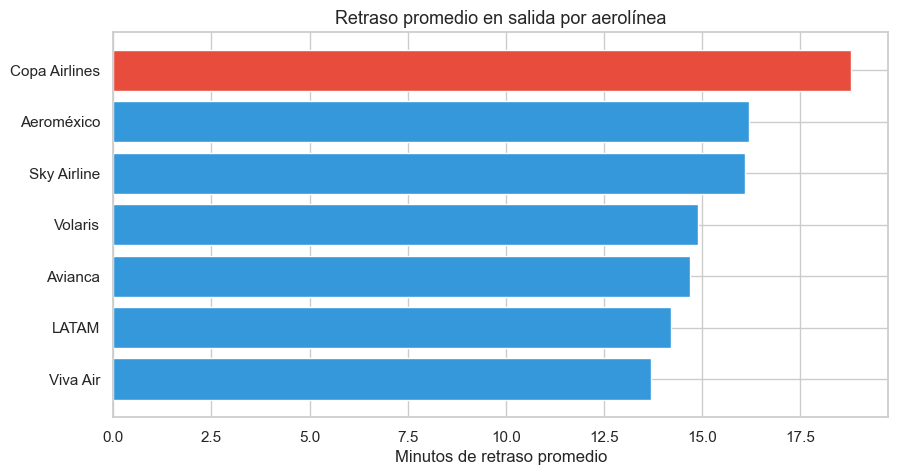

Rojo = aerolínea con mayor retraso promedio


In [38]:
# Visualización: retraso promedio por aerolínea
plt.figure(figsize=(10, 5))
colores = ['#e74c3c' if v == retraso_por_aero.max() else '#3498db'
           for v in retraso_por_aero.values]
plt.barh(retraso_por_aero.index, retraso_por_aero.values, color=colores)
plt.title('Retraso promedio en salida por aerolínea', fontsize=13)
plt.xlabel('Minutos de retraso promedio')
plt.gca().invert_yaxis()
plt.show()
print('Rojo = aerolínea con mayor retraso promedio')

In [39]:
# Tasa de cancelación por aerolínea
cancel_aero = (
    df.groupby('aerolinea')['cancelado']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)
print('% de vuelos cancelados por aerolínea:')
cancel_aero

% de vuelos cancelados por aerolínea:


aerolinea
Aeroméxico      3.95
Avianca         3.78
LATAM           2.98
Volaris         2.88
Copa Airlines   2.42
Viva Air        2.11
Sky Airline     2.05
Name: cancelado, dtype: float64

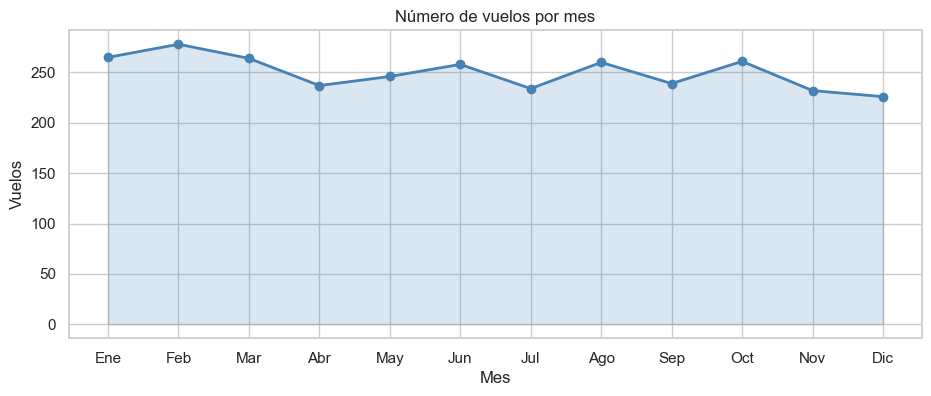

In [40]:
# Vuelos por mes — ¿hay estacionalidad?
vuelos_mes = df.groupby('mes').size()

plt.figure(figsize=(11, 4))
plt.plot(vuelos_mes.index, vuelos_mes.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(vuelos_mes.index, vuelos_mes.values, alpha=0.2, color='steelblue')
plt.title('Número de vuelos por mes')
plt.xlabel('Mes')
plt.ylabel('Vuelos')
plt.xticks(range(1,13), ['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])
plt.show()

## 11. Resumen de hallazgos clave

| # | Hallazgo | Comando usado |
|---|---|---|
| 1 | El dataset tenía **25 filas duplicadas** | `duplicated()` |
| 2 | **`causa_retraso`** tiene ~58% nulos — nulo por diseño cuando no hay retraso | `isnull().sum()` |
| 3 | **`satisfaccion_cliente`** tiene ~6.5% nulos sin patrón claro | `isnull().mean()` |
| 4 | El retraso en salida está **muy sesgado**: mediana ~0 min, pero hay outliers >400 min | `describe()`, boxplot |
| 5 | **Precio del boleto** tiene outliers extremos (>$2 500) — posibles errores o chárters | boxplot, histograma |
| 6 | **Distancia y duración** tienen correlación muy alta (~0.98) | `corr()`, scatter |
| 7 | **Retraso salida y llegada** también correlacionan fuertemente (~0.97) | `corr()` |
| 8 | **Viva Air** es la aerolínea con mayor tasa de cancelación | `groupby()` |
| 9 | Los vuelos de **Sábado y Domingo** concentran más tráfico | `value_counts()` |
| 10 | Primera clase tiene el mayor precio medio Y la mayor satisfacción promedio | `groupby()` |

> **Próximos pasos:** limpiar nulos, tratar outliers y preparar el dataset para modelado predictivo.